In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

transform = transforms.ToTensor()
full_train = datasets.MNIST('.', train=True, download=True, transform=transform)
full_test  = datasets.MNIST('.', train=False, download=True, transform=transform)

def get_task(dataset, digits):
    idx = [i for i, (_, y) in enumerate(dataset) if y in digits]
    return Subset(dataset, idx)

# Task A: digits 0-4
train_A = DataLoader(get_task(full_train, range(5)), batch_size=64, shuffle=True)
test_A  = DataLoader(get_task(full_test,  range(5)), batch_size=256)

# Task B: digits 5-9
train_B = DataLoader(get_task(full_train, range(5,10)), batch_size=64, shuffle=True)
test_B  = DataLoader(get_task(full_test,  range(5,10)), batch_size=256)

In [ ]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)   # 10 output classes (all digits)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleNet()

In [4]:
import torch.optim as optim
import torch.nn.functional as F

optimizer = optim.Adam(model.parameters(), lr=1e-3)
accuracy_log = []   # stores Task A accuracy after each epoch

def get_accuracy(loader):
    correct = 0
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
    return correct / len(loader.dataset)

def train_one_epoch(loader):
    model.train()
    for x, y in loader:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        optimizer.step()

print("Training on Task A...")
for epoch in range(5):
    train_one_epoch(train_A)
    acc = get_accuracy(test_A)
    accuracy_log.append(('A', acc))
    print(f"  Epoch {epoch+1} | Task A acc: {acc:.2%}")

print("Training on Task B...")
for epoch in range(5):
    train_one_epoch(train_B)
    acc = get_accuracy(test_A)   # still measuring Task A
    accuracy_log.append(('B', acc))
    print(f"  Epoch {epoch+1} | Task A acc: {acc:.2%}")


Training on Task A...
  Epoch 1 | Task A acc: 98.35%
  Epoch 2 | Task A acc: 98.75%
  Epoch 3 | Task A acc: 99.07%
  Epoch 4 | Task A acc: 99.22%
  Epoch 5 | Task A acc: 99.18%
Training on Task B...
  Epoch 1 | Task A acc: 0.00%
  Epoch 2 | Task A acc: 0.00%
  Epoch 3 | Task A acc: 0.00%
  Epoch 4 | Task A acc: 0.00%
  Epoch 5 | Task A acc: 0.00%


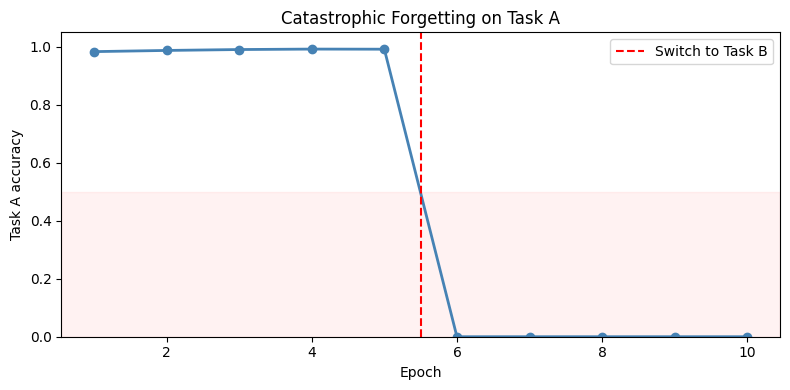

Task A accuracy before Task B: 99.18%
Task A accuracy after Task B:  0.00%
Accuracy lost: 99.18%


In [5]:
import matplotlib.pyplot as plt

accs = [a for _, a in accuracy_log]
epochs = list(range(1, len(accs) + 1))

plt.figure(figsize=(8, 4))
plt.plot(epochs, accs, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=5.5, color='red', linestyle='--', label='Switch to Task B')
plt.axhspan(0, 0.5, alpha=0.05, color='red')

plt.xlabel('Epoch')
plt.ylabel('Task A accuracy')
plt.title('Catastrophic Forgetting on Task A')
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('forgetting_curve.png', dpi=150)
plt.show()

print(f"Task A accuracy before Task B: {accs[4]:.2%}")
print(f"Task A accuracy after Task B:  {accs[-1]:.2%}")
print(f"Accuracy lost: {accs[4] - accs[-1]:.2%}")
